# BEE 4750 Homework 4: Linear Programming and Capacity Expansion

**Name**:

**ID**:

> **Due Date**
>
> Thursday, 11/07/23, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to formulate and solve a resource allocation
    problem using linear programming.
-   Problem 2 asks you to formulate, solve, and analyze a standard
    generating capacity expansion problem.
-   Problem 3 (5750 only) asks you to add a CO<sub>2</sub> constraint to
    the capacity expansion problem and identify changes in the resulting
    solution.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\26410\Desktop\Environment A\hw4-b-b`


In [2]:
using JuMP
using HiGHS
using DataFrames
using Plots
using Measures
using CSV
using MarkdownTables

## Problems (Total: 50/60 Points)

### Problem 1 (20 points)

A farmer has access to a pesticide which can be used on corn, soybeans,
and wheat fields, and costs \$70/ha-yr to apply. The crop yields the
farmer can obtain following crop yields by applying varying rates of
pesticides to the field are shown in
<a href="#tbl-yields" class="quarto-xref">Table 1</a>.

| Application Rate (kg/ha) | Soybean (kg/ha) | Wheat (kg/ha) | Corn (kg/ha) |
|:------------------------:|:---------------:|:-------------:|:------------:|
|            0             |      2900       |     3500      |     5900     |
|            1             |      3800       |     4100      |     6700     |
|            2             |      4400       |     4200      |     7900     |

Table 1: Crop yields from applying varying pesticide rates for Problem
1.

The costs of production, *excluding pesticides*, for each crop, and
selling prices, are shown in
<a href="#tbl-costs" class="quarto-xref">Table 2</a>.

|   Crop   | Production Cost (\$/ha-yr) | Selling Price (\$/kg) |
|:--------:|:--------------------------:|:---------------------:|
| Soybeans |            350             |         0.36          |
|  Wheat   |            280             |         0.27          |
|   Corn   |            390             |         0.22          |

Table 2: Costs of crop production, excluding pesticides, and selling
prices for each crop.

Recently, environmental authorities have declared that farms cannot have
an *average* application rate on soybeans, wheat, and corn which exceeds
0.8, 0.7, and 0.6 kg/ha, respectively. The farmer has asked you for
advice on how they should plant crops and apply pesticides to maximize
profits over 130 total ha while remaining in regulatory compliance if
demand for each crop (which is the maximum the market would buy) this
year is 250,000 kg?

**In this problem**:

-   Formulate a linear program for this resource allocation problem,
    including clear definitions of decision variable(s) (including
    units), objective function(s), and constraint(s) (make sure to
    explain functions and constraints with any needed derivations and
    explanations). **Tip: Make sure that all of your constraints are
    linear**.
-   Implement the program in `JuMP.jl` and find the solution. How many
    ha should the farmer dedicate to each crop and with what pesticide
    application rate(s)? How much profit will the farmer expect to make?
-   The farmer has an opportunity to buy an extra 10 ha of land. How
    much extra profit would this land be worth to the farmer? Discuss
    why this value makes sense and whether you would recommend the
    farmer should make the purchase.

- \( x_s \) = Area to plant **soybeans**(ha).
- \( x_w \) = Area to plant **wheat**(ha).
- \( x_c \) = Area to plant **corn**(ha).
  
- \( z_s0 \): Area where application rate is 0 kg/ha for soybean.
- \( z_s1 \): Area where application rate is 1 kg/ha for soybean.
- \( z_s2 \): Area where application rate is 2 kg/ha for soybean.

similar:
- \( z_w0, z_w1, z_w2 \)
- \( z_c0, z_c1, z_c2 \)


p_{s0} + p_{s1} + p_{s2} = x_s

p_{w0} + p_{w1} + p_{w2} = x_w

p_{c0} + p_{c1} + p_{c2} = x_c

#### **Soybeans Profit**
P_S = (2900 $\times$ z_s0 + 3800 $\times$ z_s1 + 4400 $\times$ z_s2) $\times$ 0.36 - (x_s $\times$ 350 + 70 $\times$ (1 $\times$ z_s1 + 2 $\times$ z_s2)) 

#### **Wheat Profit**
P_W = (3500 $\times$ z_w0 + 4100 $\times$ z_w1 + 4200 $\times$ z_w2) $\times$ 0.27 - (x_w $\times$ 280 + 70 $\times$（1 $\times$ z_w1 + 2 $\times$ z_w2)) 

#### **Corn Profit**
P_C = (5900 $\times$ z_c0 + 6700 $\times$ z_c1 + 7900 $\times$ z_c2) $\times$ 0.22 - (x_c $\times$ 390 + 70 $\times$ (1 $\times$ z_c1 + 2 $\times$ z_c2)) 

#### **Object function**

max Z = P_S + P_W + P_C

#### **Constraint**
1. The total area: x_s + x_w + x_c $\leq$ 130


2. Application Rate limits on the **average** pesticide application rates:
- For soybeans: 1 $\times$ z_s1 + 2 $\times$ z_s2 $\leq$ 0.8 $\times$ x_s

- For wheat: 1 $\times$ z_w1 + 2 $\times$ z_w2 $\leq$ 0.7 $\times$ x_w

- For corn: 1 $\times$ z_c1 + 2 $\times$ z_c2 $\leq$ 0.6 $\times$ x_c

3. Production Limit:

- (2900 $\times$ z_s0 + 3800 $\times$ z_s1 + 4400 $\times$ z_s2) $\leq$ 250,000(KG)

- (3500 $\times$ z_w0 + 4100 $\times$ z_w1 + 4200 $\times$ z_w2) $\leq$ 250,000(KG)

- (5900 $\times$ z_c0 + 6700 $\times$ z_c1 + 7900 $\times$ z_c2) $\leq$ 250,000(KG)


In [7]:
model = Model(HiGHS.Optimizer)

@variable(model, z_s0 >= 0)  # Area where application rate is 0 kg/ha for soybean.
@variable(model, z_s1 >= 0)  # Area where application rate is 1 kg/ha for soybean.
@variable(model, z_s2 >= 0)  # Area where application rate is 2 kg/ha for soybean.

@variable(model, z_w0 >= 0)  # Area where application rate is 0 kg/ha for soybean.
@variable(model, z_w1 >= 0)  # Area where application rate is 1 kg/ha for soybean.
@variable(model, z_w2 >= 0)  # Area where application rate is 2 kg/ha for soybean.

@variable(model, z_c0 >= 0)  # Area where application rate is 0 kg/ha for soybean.
@variable(model, z_c1 >= 0)  # Area where application rate is 1 kg/ha for soybean.
@variable(model, z_c2 >= 0)  # Area where application rate is 2 kg/ha for soybean.

# objective
@objective(model, Max, 
    # soybeans profit
    (z_s0 * 2900 + z_s1 * 3800 + z_s2 * 4400) * 0.36 - (350 * (z_s0 + z_s1 + z_s2) + 70 * (z_s1 + 2 * z_s2)) +
    # wheat profit
    (z_w0 * 3500 + z_w1 * 4100 + z_w2 * 4200) * 0.27 - (280 * (z_w0 + z_w1 + z_w2) + 70 * (z_w1 + 2 * z_w2)) +
    # corn profit
    (z_c0 * 5900 + z_c1 * 6700 + z_c2 * 7900) * 0.22 - (390 * (z_c0 + z_c1 + z_c2) + 70 * (z_c1 + 2 * z_c2))
)

# constraint

# total land area
@constraint(model, (z_s0 + z_s1 + z_s2) + (z_w0 + z_w1 + z_w2) + (z_c0 + z_c1 + z_c2) <= 130)

# application limit rate for soybeans
@constraint(model, 0.2 * z_s1 + 1.2 * z_s2 - 0.8 * z_s0 <= 0)

# application limit rate for wheat
@constraint(model, 0.3 * z_w1 + 1.3 * z_w2 - 0.7 * z_w0 <= 0) 

# application limit rate for corn
@constraint(model, 0.4 * z_c1 + 1.4 * z_c2 - 0.6 * z_c0 <= 0) 

# 约束 5：每种作物的总产量不能超过 250,000 公斤
@constraint(model, z_s0 * 2900 + z_s1 * 3800 + z_s2 * 4400 <= 250000)  # 大豆产量
@constraint(model, z_w0 * 3500 + z_w1 * 4100 + z_w2 * 4200 <= 250000)  # 小麦产量
@constraint(model, z_c0 * 5900 + z_c1 * 6700 + z_c2 * 7900 <= 250000)  # 玉米产量

# 求解模型
optimize!(model)

# 提取结果
z_s0_opt = value(z_s0)
z_s1_opt = value(z_s1)
z_s2_opt = value(z_s2)

z_w0_opt = value(z_w0)
z_w1_opt = value(z_w1)
z_w2_opt = value(z_w2)

z_c0_opt = value(z_c0)
z_c1_opt = value(z_c1)
z_c2_opt = value(z_c2)

profit_opt = objective_value(model)


Running HiGHS 1.7.2 (git hash: 5ce7a2753): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [2e-01, 8e+03]
  Cost   [7e+02, 1e+03]
  Bound  [0e+00, 0e+00]
  RHS    [1e+02, 2e+05]
Presolving model
7 rows, 9 cols, 27 nonzeros  0s
7 rows, 9 cols, 27 nonzeros  0s
Presolve : Reductions: rows 7(-0); columns 9(-0); elements 27(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.8170297740e+02 Ph1: 7(28.3601); Du: 9(181.703) 0s
          7     1.1674116702e+05 Pr: 0(0) 0s
Model   status      : Optimal
Simplex   iterations: 7
Objective value     :  1.1674116702e+05
HiGHS run time      :          0.00


116741.16702082448

In [4]:
println("Optimal land allocation for soybeans:")
println("  Soybeans with 0 kg/ha: ", z_s0_opt, " ha")
println("  Soybeans with 1 kg/ha: ", z_s1_opt, " ha")
println("  Soybeans with 2 kg/ha: ", z_s2_opt, " ha")

println("\nOptimal land allocation for wheat:")
println("  Wheat with 0 kg/ha: ", z_w0_opt, " ha")
println("  Wheat with 1 kg/ha: ", z_w1_opt, " ha")
println("  Wheat with 2 kg/ha: ", z_w2_opt, " ha")

println("\nOptimal land allocation for corn:")
println("  Corn with 0 kg/ha: ", z_c0_opt, " ha")
println("  Corn with 1 kg/ha: ", z_c1_opt, " ha")
println("  Corn with 2 kg/ha: ", z_c2_opt, " ha")

println("\nExpected total profit: \$", profit_opt)

Optimal land allocation for soybeans:
  Soybeans with 0 kg/ha: 13.81215469613259 ha
  Soybeans with 1 kg/ha: 55.24861878453042 ha
  Soybeans with 2 kg/ha: 0.0 ha

Optimal land allocation for wheat:
  Wheat with 0 kg/ha: 6.7433064173395625 ha
  Wheat with 1 kg/ha: 15.734381640458983 ha
  Wheat with 2 kg/ha: 0.0 ha

Optimal land allocation for corn:
  Corn with 0 kg/ha: 26.923076923076913 ha
  Corn with 1 kg/ha: 0.0 ha
  Corn with 2 kg/ha: 11.538461538461526 ha

Expected total profit: $116741.16702082448


In [11]:
# 创建模型
model = Model(HiGHS.Optimizer)

# 决策变量：每种作物在不同农药施用率下的种植面积（公顷）
@variable(model, z_s0 >= 0)  # 大豆在 0 kg/ha 农药施用率下的面积
@variable(model, z_s1 >= 0)  # 大豆在 1 kg/ha 农药施用率下的面积
@variable(model, z_s2 >= 0)  # 大豆在 2 kg/ha 农药施用率下的面积

@variable(model, z_w0 >= 0)  # 小麦在 0 kg/ha 农药施用率下的面积
@variable(model, z_w1 >= 0)  # 小麦在 1 kg/ha 农药施用率下的面积
@variable(model, z_w2 >= 0)  # 小麦在 2 kg/ha 农药施用率下的面积

@variable(model, z_c0 >= 0)  # 玉米在 0 kg/ha 农药施用率下的面积
@variable(model, z_c1 >= 0)  # 玉米在 1 kg/ha 农药施用率下的面积
@variable(model, z_c2 >= 0)  # 玉米在 2 kg/ha 农药施用率下的面积

# 目标函数：最大化利润
@objective(model, Max, 
    # 大豆利润
    (z_s0 * 2900 + z_s1 * 3800 + z_s2 * 4400) * 0.36 -
    (350 * (z_s0 + z_s1 + z_s2) + 70 * (z_s1 + 2 * z_s2)) +
    # 小麦利润
    (z_w0 * 3500 + z_w1 * 4100 + z_w2 * 4200) * 0.27 -
    (280 * (z_w0 + z_w1 + z_w2) + 70 * (z_w1 + 2 * z_w2)) +
    # 玉米利润
    (z_c0 * 5900 + z_c1 * 6700 + z_c2 * 7900) * 0.22 -
    (390 * (z_c0 + z_c1 + z_c2) + 70 * (z_c1 + 2 * z_c2))
)

# 约束条件

# 约束 1：总土地面积不能超过 130 公顷
@constraint(model, (z_s0 + z_s1 + z_s2) + (z_w0 + z_w1 + z_w2) + (z_c0 + z_c1 + z_c2) <= 140)

# 约束 2：大豆的平均农药施用率不能超过 0.8 kg/ha
@constraint(model, 0.2 * z_s1 + 1.2 * z_s2 - 0.8 * z_s0 <= 0)

# 约束 3：小麦的平均农药施用率不能超过 0.7 kg/ha
@constraint(model, 0.3 * z_w1 + 1.3 * z_w2 - 0.7 * z_w0 <= 0) 

# 约束 4：玉米的平均农药施用率不能超过 0.6 kg/ha
@constraint(model, 0.4 * z_c1 + 1.4 * z_c2 - 0.6 * z_c0 <= 0) 

# 约束 5：每种作物的总产量不能超过 250,000 公斤
@constraint(model, z_s0 * 2900 + z_s1 * 3800 + z_s2 * 4400 <= 250000)  # 大豆产量
@constraint(model, z_w0 * 3500 + z_w1 * 4100 + z_w2 * 4200 <= 250000)  # 小麦产量
@constraint(model, z_c0 * 5900 + z_c1 * 6700 + z_c2 * 7900 <= 250000)  # 玉米产量

# 求解模型
optimize!(model)

# 提取结果
z_s0_opt = value(z_s0)
z_s1_opt = value(z_s1)
z_s2_opt = value(z_s2)

z_w0_opt = value(z_w0)
z_w1_opt = value(z_w1)
z_w2_opt = value(z_w2)

z_c0_opt = value(z_c0)
z_c1_opt = value(z_c1)
z_c2_opt = value(z_c2)

profit_opt = objective_value(model)


Running HiGHS 1.7.2 (git hash: 5ce7a2753): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [2e-01, 8e+03]
  Cost   [7e+02, 1e+03]
  Bound  [0e+00, 0e+00]
  RHS    [1e+02, 2e+05]
Presolving model
7 rows, 9 cols, 27 nonzeros  0s
7 rows, 9 cols, 27 nonzeros  0s
Presolve : Reductions: rows 7(-0); columns 9(-0); elements 27(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.8170297740e+02 Ph1: 7(28.3601); Du: 9(181.703) 0s
          7     1.2403516702e+05 Pr: 0(0) 0s
Model   status      : Optimal
Simplex   iterations: 7
Objective value     :  1.2403516702e+05
HiGHS run time      :          0.00


124035.16702082445

In [12]:
println("Optimal land allocation for soybeans:")
println("  Soybeans with 0 kg/ha: ", z_s0_opt, " ha")
println("  Soybeans with 1 kg/ha: ", z_s1_opt, " ha")
println("  Soybeans with 2 kg/ha: ", z_s2_opt, " ha")

println("\nOptimal land allocation for wheat:")
println("  Wheat with 0 kg/ha: ", z_w0_opt, " ha")
println("  Wheat with 1 kg/ha: ", z_w1_opt, " ha")
println("  Wheat with 2 kg/ha: ", z_w2_opt, " ha")

println("\nOptimal land allocation for corn:")
println("  Corn with 0 kg/ha: ", z_c0_opt, " ha")
println("  Corn with 1 kg/ha: ", z_c1_opt, " ha")
println("  Corn with 2 kg/ha: ", z_c2_opt, " ha")

println("\nExpected total profit: \$", profit_opt)

Optimal land allocation for soybeans:
  Soybeans with 0 kg/ha: 13.81215469613259 ha
  Soybeans with 1 kg/ha: 55.2486187845304 ha
  Soybeans with 2 kg/ha: 0.0 ha

Optimal land allocation for wheat:
  Wheat with 0 kg/ha: 9.743306417339564 ha
  Wheat with 1 kg/ha: 22.734381640458984 ha
  Wheat with 2 kg/ha: 0.0 ha

Optimal land allocation for corn:
  Corn with 0 kg/ha: 26.923076923076923 ha
  Corn with 1 kg/ha: 0.0 ha
  Corn with 2 kg/ha: 11.538461538461522 ha

Expected total profit: $124035.16702082445


### Problem 2 (30 points)

For this problem, we will use hourly load (demand) data from 2013 in New
York’s Zone C (which includes Ithaca). The load data is loaded and
plotted below in <a href="#fig-demand" class="quarto-xref">Figure 1</a>.

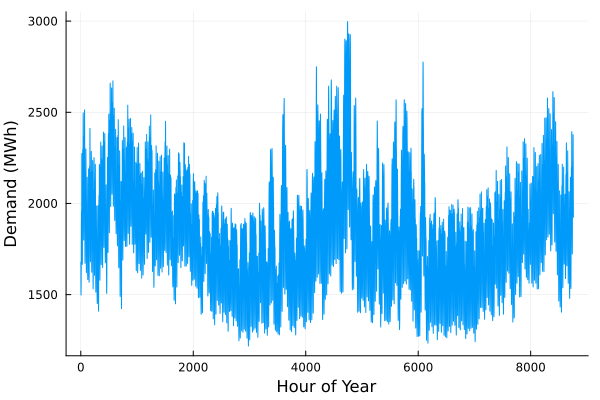

In [13]:
# load the data, pull Zone C, and reformat the DataFrame
NY_demand = DataFrame(CSV.File("data/2013_hourly_load_NY.csv"))
rename!(NY_demand, :"Time Stamp" => :Date)
demand = NY_demand[:, [:Date, :C]]
rename!(demand, :C => :Demand)
demand[:, :Hour] = 1:nrow(demand)

# plot demand
plot(demand.Hour, demand.Demand, xlabel="Hour of Year", ylabel="Demand (MWh)", label=:false)

Next, we load the generator data, shown in
<a href="#tbl-generators" class="quarto-xref">Table 3</a>. This data
includes fixed costs (\$/MW installed), variable costs (\$/MWh
generated), and CO<sub>2</sub> emissions intensity (tCO<sub>2</sub>/MWh
generated).

In [14]:
gens = DataFrame(CSV.File("data/generators.csv"))

Row,Plant,FixedCost,VarCost,Emissions
,String15,Int64,Int64,Float64
1,Geothermal,450000,0,0.0
2,Coal,220000,24,1.0
3,NG CCGT,82000,30,0.43
4,NG CT,65000,40,0.55
5,Wind,91000,0,0.0
6,Solar,70000,0,0.0


Finally, we load the hourly solar and wind capacity factors, which are
plotted in <a href="#fig-cf" class="quarto-xref">Figure 2</a>. These
tell us the fraction of installed capacity which is expected to be
available in a given hour for generation (typically based on the average
meteorology).

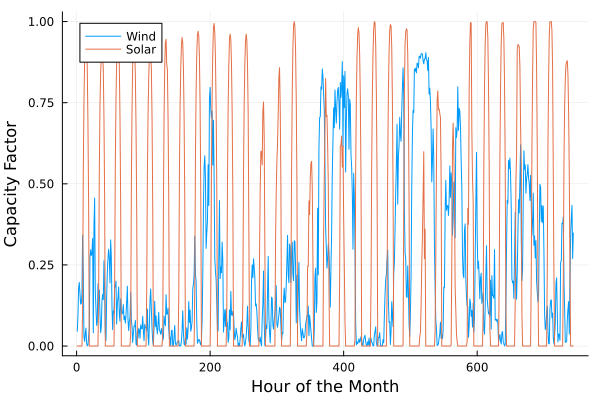

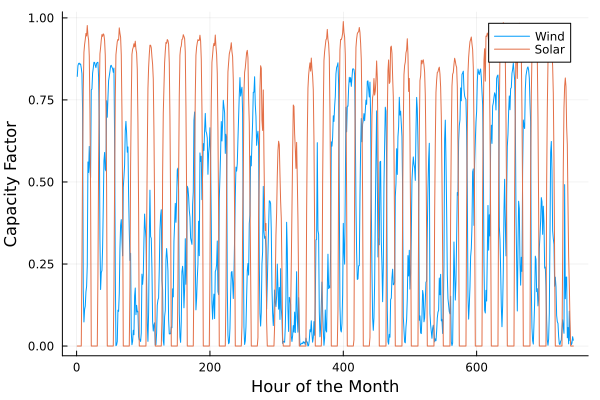

In [15]:
# load capacify factors into a DataFrame
cap_factor = DataFrame(CSV.File("data/wind_solar_capacity_factors.csv"))

# plot January capacity factors
p1 = plot(cap_factor.Wind[1:(24*31)], label="Wind")
plot!(cap_factor.Solar[1:(24*31)], label="Solar")
xaxis!("Hour of the Month")
yaxis!("Capacity Factor")

p2 = plot(cap_factor.Wind[4344:4344+(24*31)], label="Wind")
plot!(cap_factor.Solar[4344:4344+(24*31)], label="Solar")
xaxis!("Hour of the Month")
yaxis!("Capacity Factor")

display(p1)
display(p2)

You have been asked to develop a generating capacity expansion plan for
the utility in Riley County, NY, which currently has no existing
electrical generation infrastructure. The utility can build any of the
following plant types: geothermal, coal, natural gas combined cycle gas
turbine (CCGT), natural gas combustion turbine (CT), solar, and wind.

While coal, CCGT, and CT plants can generate at their full installed
capacity, geothermal plants operate at maximum 85% capacity, and solar
and wind available capacities vary by the hour depend on the expected
meteorology. The utility will also penalize any non-served demand at a
rate of \$10,000/MWh.

**In this problem**:

-   Formulate a linear program for this capacity expansion problem,
    including clear definitions of decision variable(s) (including
    units), objective function(s), and constraint(s) (make sure to
    explain functions and constraints with any needed derivations and
    explanations).
-   Implement your linear program in `JuMP.jl`. Find the optimal
    solution. How much should the utility build of each type of
    generating plant? What will the total cost be? How much energy will
    be non-served?
-   What fraction of annual generation does each plant type produce? How
    does this compare to the breakdown of built capacity that you found
    in Problem 1.5? Do these results make sense given the generator
    data?
-   Make a plot of the electricity price in each hour. Discuss any
    trends that you see.

> **Significant Digits**
>
> Use `round(x; digits=n)` to report values to the appropriate
> precision! If your number is on a different order of magnitude and you
> want to round to a certain number of significant digits, you can use
> `round(x; sigdigits=n)`.

> **Getting Variable Output Values**
>
> `value.(x)` will report the values of a `JuMP` variable `x`, but it
> will return a special container which holds other information about
> `x` that is useful for `JuMP`. This means that you can’t use this
> output directly for further calculations. To just extract the values,
> use `value.(x).data`.

> **Suppressing Model Command Output**
>
> The output of specifying model components (variable or constraints)
> can be quite large for this problem because of the number of time
> periods. If you end a cell with an `@variable` or `@constraint`
> command, I *highly* recommend suppressing output by adding a
> semi-colon after the last command, or you might find that your
> notebook crashes.

- **Installed Capacity**: 
  - $x_{geo}$ : Installed capacity of geothermal power (MW).
  - $x_{coal}$: Installed capacity of coal power (MW).
  - $x_{CCGT}$: Installed capacity of combined cycle gas turbine (CCGT) power (MW).
  - $x_{CT}$: Installed capacity of combustion turbine (CT) power (MW).
  - $x_{solar}$: Installed capacity of solar power (MW).
  - $x_{wind}$: Installed capacity of wind power (MW).
  - $x_{g}$ = {$x_{geo}$, $x_{coal}$, $x_{CCGT}$, $x_{CT}$, $x_{solar}$, $x_{wind}$}

- **Generation**: 
  - $y_{geo}(t)$: Generation by geothermal at t.(MWh)
  - $y_{coal}(t)$: Generation by coal at hour t.(MWh)
  - $y_{CCGT}(t)$: Generation by CCGT at hour t.(MWh)
  - $y_{CT}(t)$: Generation by CT at hour t.(MWh)
  - $y_{solar}(t)$: Generation by solar at hour t.(MWh)
  - $y_{wind}(t)$: Generation by wind at hour \t.(MWh)
  - $y_{g}(t)$ = {$y_{geo}(t)$, $y_{coal}(t)$, $y_{CCGT}(t)$, $y_{CT}(t)$, $y_{solar}(t)$, $y_{wind}(t)$:}
- **Unserved Demand**: 
  - NSE(t): Unmet demand at hour t (MWh).


\begin{align*}
\text{min}_{cost} \quad & \sum_{g \in \mathcal{G}} \text{FixedCost}_g \times x_g 
+ \sum_{t \in \mathcal{T}} \sum_{g \in \mathcal{G}} \text{VarCost}_g \times y_{g,t} 
+ \sum_{t \in \mathcal{T}} \text{NSECost} \times NSE_t \\
\text{constraints:} \quad & \sum_{g \in \mathcal{G}} y_{g,t} + NSE_t \geq d_t, \quad \forall t \in \mathcal{T} \\
& y_{g,t} \leq x_g, \quad \forall g \in \mathcal{G}, \forall t \in \mathcal{T} \\
& x_g, y_{g,t}, NSE_t \geq 0, \quad \forall g \in \mathcal{G}, \forall t \in \mathcal{T}
\end{align*}

In [20]:
# Load demand data 
NY_demand = DataFrame(CSV.File("data/2013_hourly_load_NY.csv"))
rename!(NY_demand, "Time Stamp" => :Date)
demand = NY_demand[!, :C]  
demand = convert(Array{Float64}, demand) 
T = length(demand)  

# Load generator data 
gens = DataFrame(CSV.File("data/generators.csv"))
FixedCost = gens.FixedCost  # FixedCost
VarCost = gens.VarCost  # varcost
G = size(gens, 1)  # amount

# Load wind and solar capacity factors
cap_factor = DataFrame(CSV.File("data/wind_solar_capacity_factors.csv"))
CapacityFactor_wind = cap_factor[1:T, :Wind] 
CapacityFactor_solar = cap_factor[1:T, :Solar]  

# Non-served energy cost ($10,000 per MWh)
NSECost = 10000

model = Model(HiGHS.Optimizer)

@variable(model, x[1:G] >= 0)  # installed capacity（MW）
@variable(model, y[1:G, 1:T] >= 0)  # gengeration（MWh）
@variable(model, NSE[1:T] >= 0)  # unserved demand（MWh）

# objective
@objective(model, Min, 
    # fixedcost
    sum(FixedCost[g] * x[g] for g in 1:G) +
    # varcost
    sum(VarCost[g] * y[g,t] for g in 1:G, t in 1:T) +
    # publish(NES)
    sum(NSECost * NSE[t] for t in 1:T)
)

# constraint

# 1. demand and unserved
for t in 1:T
    @constraint(model, sum(y[g,t] for g in 1:G) + NSE[t] >= demand[t])
end

# 2. less than capacity
for g in 1:G, t in 1:T
    if gens.Plant[g] == "Wind"  # for wind plant
        @constraint(model, y[g,t] <= x[g] * CapacityFactor_wind[t])
    elseif gens.Plant[g] == "Solar"  # for solar plant
        @constraint(model, y[g,t] <= x[g] * CapacityFactor_solar[t])
    elseif gens.Plant[g] == "Geothermal"  # 0.85 max for geothermal plant
        @constraint(model, y[g,t] <= x[g] * 0.85)
    else  
        @constraint(model, y[g,t] <= x[g])
    end
end

optimize!(model)


Running HiGHS 1.7.2 (git hash: 5ce7a2753): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [5e-05, 1e+00]
  Cost   [2e+01, 4e+05]
  Bound  [0e+00, 0e+00]
  RHS    [1e+03, 3e+03]
Presolving model
56856 rows, 56862 cols, 153048 nonzeros  0s
56853 rows, 56859 cols, 153042 nonzeros  0s
Presolve : Reductions: rows 56853(-4467); columns 56859(-4467); elements 153042(-8934)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(4.12704e+06) 0s
      41998     6.5458487038e+08 Pr: 0(0); Du: 0(6.60805e-13) 2s
Solving the original LP from the solution after postsolve
Model   status      : Optimal
Simplex   iterations: 41998
Objective value     :  6.5458487038e+08
HiGHS run time      :          2.39


In [22]:
x_opt = value.(x)  
y_opt = value.(y)  
NSE_opt = value.(NSE)  
total_cost = objective_value(model)  

# print
println("\n The optimal installed capacity of each power station(MW):")
for g in 1:G
    println(gens.Plant[g], ": ", x_opt[g])
end

println("\n total cost: \$", total_cost)
println("\n unserved (MWh): ", sum(NSE_opt))
else



 The optimal installed capacity of each power station(MW):
Geothermal: -0.0
Coal: 0.0
NG CCGT: 1658.4514133074133
NG CT: 879.7538120149645
Wind: 484.946167110047
Solar: 1957.6424239086684

 total cost: $6.545848703815941e8

 unserved (MWh): 256.83377442738583


In [26]:
# General 
GeneralE = zeros(G)  
for g in 1:G
    for t in 1:T
        GeneralE[g] += value(y[g, t])  # Summing generation for plant g over all hours t
    end
end

# Total annual generation across all plants
TotalGeneration = sum(GeneralE)

# Fraction of annual generation for each plant type
Fraction = GeneralE ./ TotalGeneration

println("\nFraction of annual generation for each plant type:")
for g in 1:G
    println(gens.Plant[g], ": ", round(Fraction[g] * 100, digits=2), "%")
end


Fraction of annual generation for each plant type:
Geothermal: 0.0%
Coal: 0.0%
NG CCGT: 52.89%
NG CT: 2.75%
Wind: 8.72%
Solar: 35.65%


The results make sense based on the generator data. NG CCGT is the most economical for sustained generation. And wind and solar, while having large capacities, contribute a smaller portion of generation due to their lower capacity factors. 

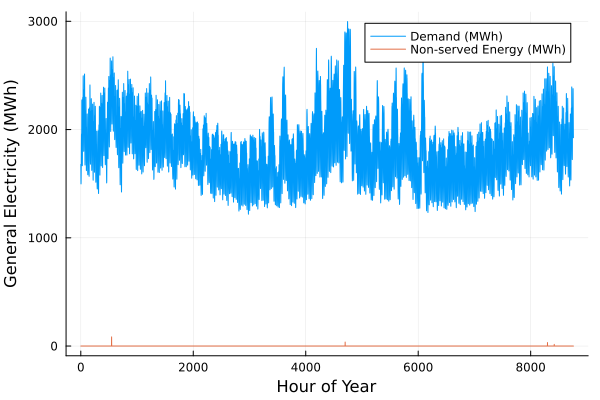

In [25]:
plot(1:T, demand, label="Demand (MWh)", xlabel="Hour of Year", ylabel="General Electricity (MWh)")
plot!(1:T, NSE_opt, label="Non-served Energy (MWh)")

The demand curve follows a seasonal pattern. There is a noticeable higher demand in the beginning, the middle and the end of the year (during summer and winter months), and during the spring and the autumn, the general electricity is low.

### Problem 3 (10 points)

**This problem is only required for students in BEE 5750**.

The NY state legislature is considering enacting an annual
CO<sub>2</sub> limit, which for the utility would limit the emissions in
its footprint to 1.5 MtCO<sub>2</sub>/yr.

**In this problem**:

-   Reformulate your linear program from Problem 2 with any necessary
    changes to capture the CO<sub>2</sub> limit.
-   Implement the new optimization problem and find the optimal
    solution. How much should the utility build of each type of
    generating plant? What is different from your plan from Problem 1?
    Do these changes make sense?
-   What would the value to the utility be of allowing it to emit an
    additional 1000 tCO<sub>2</sub>/yr? An additional 5000?

Add a constraint: CO2 emission limit:

$\sum_{g \in G}$ $\sum_{t \in T}$ $Emissions_g$ x $y_{g,t}$ $\leq 1.5$ $\times 10^6$


In [28]:
# Load demand data 
NY_demand = DataFrame(CSV.File("data/2013_hourly_load_NY.csv"))
rename!(NY_demand, "Time Stamp" => :Date)
demand = NY_demand[!, :C]  
demand = convert(Array{Float64}, demand) 
T = length(demand)  

# Load generator data 
gens = DataFrame(CSV.File("data/generators.csv"))
FixedCost = gens.FixedCost  # FixedCost
VarCost = gens.VarCost  # varcost
G = size(gens, 1)  # amount

# Load wind and solar capacity factors
cap_factor = DataFrame(CSV.File("data/wind_solar_capacity_factors.csv"))
CapacityFactor_wind = cap_factor[1:T, :Wind] 
CapacityFactor_solar = cap_factor[1:T, :Solar]  

# Non-served energy cost ($10,000 per MWh)
NSECost = 10000

model = Model(HiGHS.Optimizer)

@variable(model, x[1:G] >= 0)  # installed capacity（MW）
@variable(model, y[1:G, 1:T] >= 0)  # gengeration（MWh）
@variable(model, NSE[1:T] >= 0)  # unserved demand（MWh）

# objective
@objective(model, Min, 
    # fixedcost
    sum(FixedCost[g] * x[g] for g in 1:G) +
    # varcost
    sum(VarCost[g] * y[g,t] for g in 1:G, t in 1:T) +
    # publish(NES)
    sum(NSECost * NSE[t] for t in 1:T)
)

# constraint

# 1. demand and unserved
for t in 1:T
    @constraint(model, sum(y[g,t] for g in 1:G) + NSE[t] >= demand[t])
end

# 2. less than capacity
for g in 1:G, t in 1:T
    if gens.Plant[g] == "Wind"  # for wind plant
        @constraint(model, y[g,t] <= x[g] * CapacityFactor_wind[t])
    elseif gens.Plant[g] == "Solar"  # for solar plant
        @constraint(model, y[g,t] <= x[g] * CapacityFactor_solar[t])
    elseif gens.Plant[g] == "Geothermal"  # 0.85 max for geothermal plant
        @constraint(model, y[g,t] <= x[g] * 0.85)
    else  
        @constraint(model, y[g,t] <= x[g])
    end
end

#3. co2 emission(add)
Emissions = gens.Emissions  # CO2 emmision
total_CO2_emissions = sum(Emissions[g] * y[g,t] for g in 1:G, t in 1:T)
@constraint(model, total_CO2_emissions <= 1.5e6) 

optimize!(model)


Running HiGHS 1.7.2 (git hash: 5ce7a2753): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [5e-05, 1e+00]
  Cost   [2e+01, 4e+05]
  Bound  [0e+00, 0e+00]
  RHS    [1e+03, 2e+06]
Presolving model
56857 rows, 56862 cols, 179328 nonzeros  0s
56854 rows, 56859 cols, 179322 nonzeros  0s
Presolve : Reductions: rows 56854(-4467); columns 56859(-4467); elements 179322(-8934)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(3.97118e+06) 0s
      24269     6.6133230565e+08 Pr: 20922(3.66426e+06); Du: 0(6.09407e-06) 5s
      30413     7.7846485967e+08 Pr: 10135(779654); Du: 0(5.12164e-06) 10s
      32767     7.8535295894e+08 Pr: 0(0); Du: 0(2.41585e-13) 13s
Solving the original LP from the solution after postsolve
Model   status      : Optimal
Simplex   iterations: 32767
Objective value     :  7.8535295894e+08
HiGHS run time      :         13.33


┌ Warning: The addition operator has been used on JuMP expressions a large number of times. This warning is safe to ignore but may indicate that model generation is slower than necessary. For performance reasons, you should not add expressions in a loop. Instead of x += y, use add_to_expression!(x,y) to modify x in place. If y is a single variable, you may also use add_to_expression!(x, coef, y) for x += coef*y.
└ @ JuMP C:\Users\26410\.julia\packages\JuMP\7rBNn\src\operators.jl:282


In [29]:
x_opt = value.(x)  
y_opt = value.(y)  
NSE_opt = value.(NSE)  
total_cost = objective_value(model)  

# print
println("\n The optimal installed capacity of each power station(MW):")
for g in 1:G
    println(gens.Plant[g], ": ", x_opt[g])
end

println("\n total cost: \$", total_cost)
println("\n unserved (MWh): ", sum(NSE_opt))
else



 The optimal installed capacity of each power station(MW):
Geothermal: 285.568135230671
Coal: 0.0
NG CCGT: 1509.1728698942966
NG CT: 703.0618976373753
Wind: 2548.887923366492
Solar: 2103.7493968268923

 total cost: $7.853529589434917e8

 unserved (MWh): 332.2907137925929


The result have changed because of the CO2 emission limit, as more clean energy are used now like the geothermal, the wind and the solar, this help to protect the environment but also increase the total cost.

In [31]:
# Load demand data 
NY_demand = DataFrame(CSV.File("data/2013_hourly_load_NY.csv"))
rename!(NY_demand, "Time Stamp" => :Date)
demand = NY_demand[!, :C]  
demand = convert(Array{Float64}, demand) 
T = length(demand)  

# Load generator data 
gens = DataFrame(CSV.File("data/generators.csv"))
FixedCost = gens.FixedCost  # FixedCost
VarCost = gens.VarCost  # varcost
G = size(gens, 1)  # amount

# Load wind and solar capacity factors
cap_factor = DataFrame(CSV.File("data/wind_solar_capacity_factors.csv"))
CapacityFactor_wind = cap_factor[1:T, :Wind] 
CapacityFactor_solar = cap_factor[1:T, :Solar]  

# Non-served energy cost ($10,000 per MWh)
NSECost = 10000

model = Model(HiGHS.Optimizer)

@variable(model, x[1:G] >= 0)  # installed capacity（MW）
@variable(model, y[1:G, 1:T] >= 0)  # gengeration（MWh）
@variable(model, NSE[1:T] >= 0)  # unserved demand（MWh）

# objective
@objective(model, Min, 
    # fixedcost
    sum(FixedCost[g] * x[g] for g in 1:G) +
    # varcost
    sum(VarCost[g] * y[g,t] for g in 1:G, t in 1:T) +
    # publish(NES)
    sum(NSECost * NSE[t] for t in 1:T)
)

# constraint

# 1. demand and unserved
for t in 1:T
    @constraint(model, sum(y[g,t] for g in 1:G) + NSE[t] >= demand[t])
end

# 2. less than capacity
for g in 1:G, t in 1:T
    if gens.Plant[g] == "Wind"  # for wind plant
        @constraint(model, y[g,t] <= x[g] * CapacityFactor_wind[t])
    elseif gens.Plant[g] == "Solar"  # for solar plant
        @constraint(model, y[g,t] <= x[g] * CapacityFactor_solar[t])
    elseif gens.Plant[g] == "Geothermal"  # 0.85 max for geothermal plant
        @constraint(model, y[g,t] <= x[g] * 0.85)
    else  
        @constraint(model, y[g,t] <= x[g])
    end
end

#3. co2 emission(add)
Emissions = gens.Emissions  # CO2 emmision
total_CO2_emissions = sum(Emissions[g] * y[g,t] for g in 1:G, t in 1:T)
@constraint(model, total_CO2_emissions <= 1.6e6) 

optimize!(model)

x_opt = value.(x)  
y_opt = value.(y)  
NSE_opt = value.(NSE)  
total_cost = objective_value(model)  

# print
println("\n The optimal installed capacity of each power station(MW):")
for g in 1:G
    println(gens.Plant[g], ": ", x_opt[g])
end

println("\n total cost: \$", total_cost)
println("\n unserved (MWh): ", sum(NSE_opt))
else


Running HiGHS 1.7.2 (git hash: 5ce7a2753): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [5e-05, 1e+00]
  Cost   [2e+01, 4e+05]
  Bound  [0e+00, 0e+00]
  RHS    [1e+03, 2e+06]
Presolving model
56857 rows, 56862 cols, 179328 nonzeros  0s
56854 rows, 56859 cols, 179322 nonzeros  0s
Presolve : Reductions: rows 56854(-4467); columns 56859(-4467); elements 179322(-8934)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(3.97118e+06) 0s
      25343     6.6019625529e+08 Pr: 18623(6.54447e+06); Du: 0(5.42101e-06) 5s
      31230     7.6444727969e+08 Pr: 1952(98276.7); Du: 0(5.64359e-06) 10s
      32846     7.6712679425e+08 Pr: 0(0); Du: 0(1.23066e-11) 12s
Solving the original LP from the solution after postsolve
Model   status      : Optimal
Simplex   iterations: 32846
Objective value     :  7.6712679425e+08
HiGHS run time      :         12.21

 The op

In [32]:
# Load demand data 
NY_demand = DataFrame(CSV.File("data/2013_hourly_load_NY.csv"))
rename!(NY_demand, "Time Stamp" => :Date)
demand = NY_demand[!, :C]  
demand = convert(Array{Float64}, demand) 
T = length(demand)  

# Load generator data 
gens = DataFrame(CSV.File("data/generators.csv"))
FixedCost = gens.FixedCost  # FixedCost
VarCost = gens.VarCost  # varcost
G = size(gens, 1)  # amount

# Load wind and solar capacity factors
cap_factor = DataFrame(CSV.File("data/wind_solar_capacity_factors.csv"))
CapacityFactor_wind = cap_factor[1:T, :Wind] 
CapacityFactor_solar = cap_factor[1:T, :Solar]  

# Non-served energy cost ($10,000 per MWh)
NSECost = 10000

model = Model(HiGHS.Optimizer)

@variable(model, x[1:G] >= 0)  # installed capacity（MW）
@variable(model, y[1:G, 1:T] >= 0)  # gengeration（MWh）
@variable(model, NSE[1:T] >= 0)  # unserved demand（MWh）

# objective
@objective(model, Min, 
    # fixedcost
    sum(FixedCost[g] * x[g] for g in 1:G) +
    # varcost
    sum(VarCost[g] * y[g,t] for g in 1:G, t in 1:T) +
    # publish(NES)
    sum(NSECost * NSE[t] for t in 1:T)
)

# constraint

# 1. demand and unserved
for t in 1:T
    @constraint(model, sum(y[g,t] for g in 1:G) + NSE[t] >= demand[t])
end

# 2. less than capacity
for g in 1:G, t in 1:T
    if gens.Plant[g] == "Wind"  # for wind plant
        @constraint(model, y[g,t] <= x[g] * CapacityFactor_wind[t])
    elseif gens.Plant[g] == "Solar"  # for solar plant
        @constraint(model, y[g,t] <= x[g] * CapacityFactor_solar[t])
    elseif gens.Plant[g] == "Geothermal"  # 0.85 max for geothermal plant
        @constraint(model, y[g,t] <= x[g] * 0.85)
    else  
        @constraint(model, y[g,t] <= x[g])
    end
end

#3. co2 emission(add)
Emissions = gens.Emissions  # CO2 emmision
total_CO2_emissions = sum(Emissions[g] * y[g,t] for g in 1:G, t in 1:T)
@constraint(model, total_CO2_emissions <= 2.0e6) 

optimize!(model)
 
x_opt = value.(x)  
y_opt = value.(y)  
NSE_opt = value.(NSE)  
total_cost = objective_value(model)  

# print
println("\n The optimal installed capacity of each power station(MW):")
for g in 1:G
    println(gens.Plant[g], ": ", x_opt[g])
end

println("\n total cost: \$", total_cost)
println("\n unserved (MWh): ", sum(NSE_opt))
else


Running HiGHS 1.7.2 (git hash: 5ce7a2753): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [5e-05, 1e+00]
  Cost   [2e+01, 4e+05]
  Bound  [0e+00, 0e+00]
  RHS    [1e+03, 2e+06]
Presolving model
56857 rows, 56862 cols, 179328 nonzeros  0s
56854 rows, 56859 cols, 179322 nonzeros  0s
Presolve : Reductions: rows 56854(-4467); columns 56859(-4467); elements 179322(-8934)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(3.97118e+06) 0s
      29270     6.5942969341e+08 Pr: 11203(1.04226e+07); Du: 0(5.0471e-06) 5s
      32693     7.0560595625e+08 Pr: 0(0); Du: 0(9.09495e-12) 9s
Solving the original LP from the solution after postsolve
Model   status      : Optimal
Simplex   iterations: 32693
Objective value     :  7.0560595625e+08
HiGHS run time      :          9.03

 The optimal installed capacity of each power station(MW):
Geothermal: -0.0
Coal: 0.

With the additional CO2 emission allowed, it will help the utility to decrease the cost.

## References

List any external references consulted, including classmates.